In [ ]:
# from google.colab import drive

# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/faster_rcnn
# %cp VOC2007.zip /content
# %cp VOC2012.zip /content

In [3]:
from pathlib import Path
import zipfile

data_path = Path("data/")
data_path.mkdir(exist_ok=True)

voc2007_zip_path = Path("VOC2007.zip")
voc2012_zip_path = Path("VOC2012.zip")

if not voc2007_zip_path.exists() or not voc2012_zip_path.exists():
    raise RuntimeError("Dataset not found.")

print("Extracting 2007 dataset ...")

with zipfile.ZipFile(voc2007_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

print(f"Extracting 2012 dataset ...")
with zipfile.ZipFile(voc2012_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

Extracting 2007 dataset ...
Extracting 2012 dataset ...


In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from src.backbone import backbone_transform
from src.dataset import get_voc_img_paths_train, get_voc_img_paths_test, create_voc_dataloader

transform = backbone_transform

voc2007_img_paths_train, voc2012_img_paths_train = get_voc_img_paths_train()
voc2007_img_paths_test, voc2012_img_paths_test = get_voc_img_paths_test()

combined_train_img_paths = voc2007_img_paths_train + voc2012_img_paths_train

train_dataloader = create_voc_dataloader(img_paths_list=combined_train_img_paths, transform=transform, batch_size=2, shuffle=True)

# difficult=True makes the test loader yield a 5th value (per-image bool mask over that image's GT boxes).
test_dataloader = create_voc_dataloader(img_paths_list=voc2007_img_paths_test, transform=transform, batch_size=2, shuffle=True, difficult=True)

In [22]:
from src.backbone import Backbone
from src.rpn import RPN_Head, RegionProposalNetwork
from src.roi import RoIPool
from src.detection_net import DetectionHead, DetectionNet
import torch
from pathlib import Path

# Step-1 RPN network: frozen, exists only to generate proposals.
rpn_head = RPN_Head(in_channels=1024, mid_channels=512)

# rpn_checkpoint_path = Path("/content/drive/MyDrive/faster_rcnn/checkpoints/step1_epoch_10.pt")
rpn_checkpoint_path = Path("checkpoints/step3_epoch_10.pt")
rpn_checkpoint = torch.load(rpn_checkpoint_path, map_location=device)

# backbone checkpint_path
backbone_checkpoint_path = Path("checkpoints/step2_epoch_6.pt")
backbone_checkpoint = torch.load(backbone_checkpoint_path, map_location=device)

detection_head_checkpoint_path = Path("checkpoints/step4_epoch_8.pt")
detection_head_checkpoint = torch.load(detection_head_checkpoint_path, map_location=device)

# Step-2 detection network: separate, fresh ImageNet weights, trained.
backbone = Backbone().to(device)
roi_pool = RoIPool(output_size=(7, 7), pooling_mode="adaptive").to(device)
detection_head = DetectionHead().to(device)

rpn_head.load_state_dict(rpn_checkpoint['rpn_head_state_dict'])
print(f"Loaded RPN Checkpoint: {rpn_checkpoint_path}")

backbone.load_state_dict(backbone_checkpoint['backbone_state_dict'])
print(f"Loaded Backbone Checkpoint: {backbone_checkpoint_path}")

detection_head.load_state_dict(detection_head_checkpoint['detection_head_state_dict'])
print(f"Loaded Detection Head Checkpoint: {detection_head_checkpoint_path}")

rpn_network = RegionProposalNetwork(rpn_head=rpn_head).to(device)
detection_network = DetectionNet(detection_head=detection_head, background_label=20, delta_std=(0.1, 0.1, 0.2, 0.2), score_thresh=0.3, nms_iou_thresh=0.3).to(device)

for param in backbone.parameters():
    param.requires_grad = False
for param in rpn_head.parameters():
    param.requires_grad = False
for param in detection_head.parameters():
    param.requires_grad = False

# eval() here and never train() again
backbone.eval()
rpn_head.eval()
rpn_network.eval()
detection_head.eval()
detection_network.eval()

Loaded RPN Checkpoint: checkpoints/step3_epoch_10.pt
Loaded Backbone Checkpoint: checkpoints/step2_epoch_6.pt
Loaded Detection Head Checkpoint: checkpoints/step4_epoch_8.pt


DetectionNet(
  (detection_head): DetectionHead(
    (conv5_x): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): Bottleneck(
        (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(

In [49]:
# test_dataloader is built with difficult=True, so it yields 5 values -- batch_difficult is unused here.
batch_imgs, batch_boxes, batch_labels, batch_img_sizes_before_pad, batch_difficult = next(iter(test_dataloader))

with torch.inference_mode():
    batch_imgs = batch_imgs.to(device)
    batch_gt_boxes = [boxes.to(device) for boxes in batch_boxes]         # Not needed as the functions take care, but for safety
    batch_gt_labels = [labels.to(device) for labels in batch_labels]
    
    backbone.eval()
    rpn_head.eval()
    rpn_network.eval()
    roi_pool.eval()
    detection_head.eval()
    detection_network.eval()

    batch_feature_maps = backbone(batch_imgs)
    batch_scores, batch_proposals = rpn_network(batch_feature_maps, batch_img_height=batch_imgs.shape[2],  batch_img_width=batch_imgs.shape[3], img_sizes_before_pad=batch_img_sizes_before_pad, pre_nms_top_n=6000, post_nms_top_n=2000)
    

    print(f"batch_feature_maps.shape: {batch_feature_maps.shape}")
    pooled_batch = roi_pool(batch_feature_maps, batch_proposals, batch_imgs.shape[2], batch_imgs.shape[3])

    batch_pred_labels, batch_pred_scores, batch_pred_boxes = detection_network(batch_proposals, pooled_batch, batch_img_sizes_before_pad)


batch_feature_maps.shape: torch.Size([2, 1024, 50, 57])


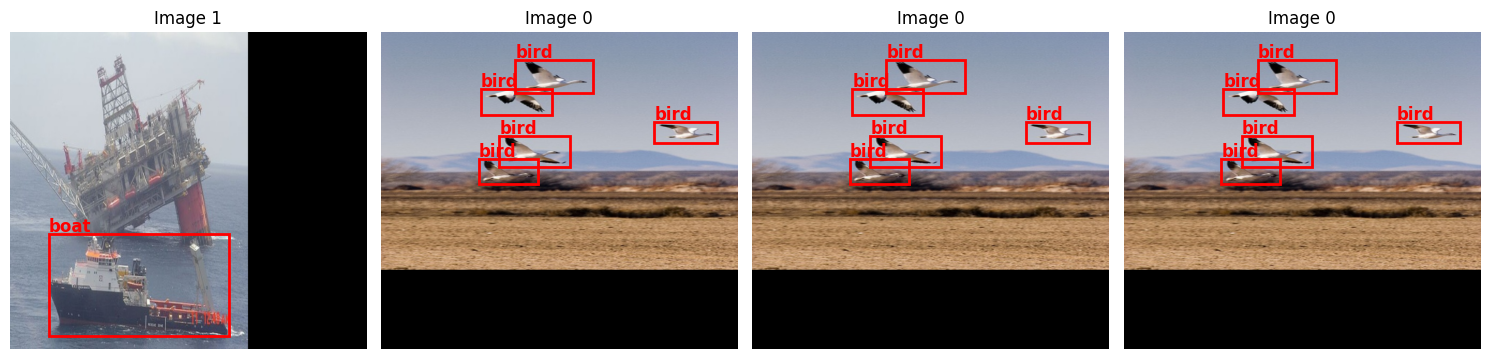

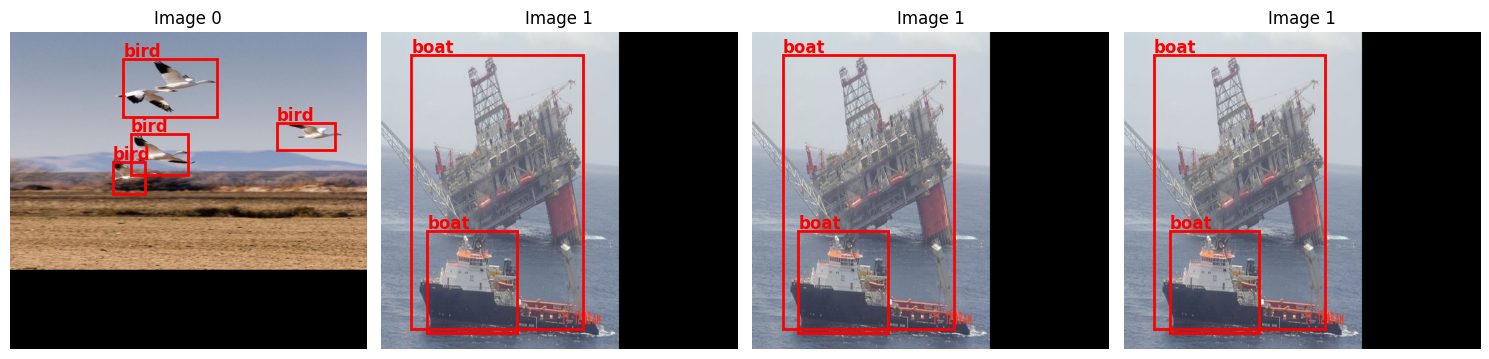

In [51]:
from src.utils import display_random_batch_images

display_random_batch_images(batch_imgs, batch_boxes, batch_labels, num_images=4)
display_random_batch_images(batch_imgs, batch_pred_boxes, batch_pred_labels, num_images=4)

In [36]:
# from torchvision.ops import batched_nms

# for i in range(len(batch_imgs)):
#     boxes = batch_pred_boxes[i]
#     scores = batch_pred_scores[i]
#     labels = batch_pred_labels[i]

#     keep_indices = batched_nms(boxes, scores, labels, iou_threshold=0.5)

#     batch_pred_boxes[i] = boxes[keep_indices]
#     batch_pred_scores[i] = scores[keep_indices]
#     batch_pred_labels[i] = labels[keep_indices]

In [37]:
# from src.utils import display_random_batch_images
# import matplotlib.pyplot as plt
# import random

# num_images = 4
# fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
# for i in range(num_images):
#     idx = random.randint(0, len(batch_imgs) - 1)
#     img = batch_imgs[idx].permute(1, 2, 0).cpu().numpy()  # Convert to HWC format and move to CPU
#     axes[i].imshow(img)
#     axes[i].set_title(f"Image {idx}")
#     axes[i].axis('off')
    
# display_random_batch_images(batch_imgs, batch_boxes, batch_labels, num_images=4)
# display_random_batch_images(batch_imgs, batch_pred_boxes, batch_pred_labels, num_images=4)

In [21]:
def compute_iou_matrix(boxes_a, boxes_b):
    # boxes_a: [num_a, 4], boxes_b: [num_b, 4] -- BOTH in CORNER format (x1, y1, x2, y2).
    # Returns: IoU matrix of shape [num_a, num_b]
    a_x1, a_y1, a_x2, a_y2 = boxes_a[:, 0], boxes_a[:, 1], boxes_a[:, 2], boxes_a[:, 3]
    b_x1, b_y1, b_x2, b_y2 = boxes_b[:, 0], boxes_b[:, 1], boxes_b[:, 2], boxes_b[:, 3]

    inter_x1 = torch.max(a_x1.unsqueeze(1), b_x1.unsqueeze(0))
    inter_y1 = torch.max(a_y1.unsqueeze(1), b_y1.unsqueeze(0))
    inter_x2 = torch.min(a_x2.unsqueeze(1), b_x2.unsqueeze(0))
    inter_y2 = torch.min(a_y2.unsqueeze(1), b_y2.unsqueeze(0))

    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)

    area_a = (a_x2 - a_x1) * (a_y2 - a_y1)
    area_b = (b_x2 - b_x1) * (b_y2 - b_y1)
    union_area = area_a.unsqueeze(1) + area_b.unsqueeze(0) - inter_area

    return inter_area / union_area

In [22]:
from tqdm import tqdm
import torchvision.ops as ops

def run_inference_full_testset(test_dataloader, backbone, rpn_network, roi_pool, detection_network, device, nms_iou_threshold=0.5, backbone_rpn=None):
    # test_dataloader MUST be built with difficult=True (5-tuple batches).
    # Returns:
    #   all_preds:         dict class_idx -> list of (score, img_id, box[4]) CORNER format, across the whole test set
    #   all_gts:           dict (img_id, class_idx) -> GT boxes tensor [num_gt, 4] CORNER format
    #   all_gts_difficult: dict (img_id, class_idx) -> bool tensor [num_gt], index-parallel to all_gts
    all_preds = {}
    all_gts = {}
    all_gts_difficult = {}

    img_id = 0

    backbone.eval()
    rpn_network.eval()
    roi_pool.eval()
    detection_network.eval()

    with torch.inference_mode():
        for batch_imgs, batch_boxes, batch_labels, batch_img_sizes_before_pad, batch_difficult in tqdm(test_dataloader):
            batch_imgs = batch_imgs.to(device)
            batch_gt_boxes = [boxes.to(device) for boxes in batch_boxes]
            batch_gt_labels = [labels.to(device) for labels in batch_labels]

            # Calculate feature maps, proposals, pooled features, and predictions
            batch_feature_maps = backbone(batch_imgs)

            _, batch_proposals = rpn_network(
                batch_feature_maps,
                batch_img_height=batch_imgs.shape[2],
                batch_img_width=batch_imgs.shape[3],
                img_sizes_before_pad=batch_img_sizes_before_pad,
                pre_nms_top_n=6000,
                post_nms_top_n=2000,
            )
            
            pooled_batch = roi_pool(batch_feature_maps, batch_proposals, batch_imgs.shape[2], batch_imgs.shape[3])
            batch_pred_labels, batch_pred_scores, batch_pred_boxes = detection_network(batch_proposals, pooled_batch, batch_img_sizes_before_pad)

            # Loop through each image in the batch and apply NMS, then store predictions and ground truths
            for i in range(len(batch_imgs)):
                pred_boxes = batch_pred_boxes[i]
                pred_scores = batch_pred_scores[i]
                pred_labels = batch_pred_labels[i]

                # if pred_boxes.shape[0] > 0:
                #     keep_idx = ops.batched_nms(pred_boxes, pred_scores, pred_labels, iou_threshold=nms_iou_threshold)
                #     pred_boxes = pred_boxes[keep_idx]
                #     pred_scores = pred_scores[keep_idx]
                #     pred_labels = pred_labels[keep_idx]

                # For each predicted box, store the score, image ID, and box coordinates in all_preds, so that w.r.t to the cls_idx, we have check the box, its score, image_id
                for cls_idx, score, box in zip(pred_labels.tolist(), pred_scores.tolist(), pred_boxes):
                    all_preds.setdefault(cls_idx, []).append((score, img_id, box.detach().cpu()))

                # Store the gt_boxes with corresponding image_id and cls_idx
                gt_boxes = batch_gt_boxes[i]
                gt_labels = batch_gt_labels[i]
                gt_difficult = batch_difficult[i]
                for cls_idx in gt_labels.unique().tolist():
                    # The SAME class mask indexes boxes and difficult flags, so the two stay
                    # index-aligned per (img_id, cls_idx). That alignment is what the whole
                    # difficult-handling correctness rests on -- do not filter them separately.
                    cls_mask = gt_labels == cls_idx
                    all_gts[(img_id, cls_idx)] = gt_boxes[cls_mask].detach().cpu()
                    all_gts_difficult[(img_id, cls_idx)] = gt_difficult[cls_mask.cpu()].cpu()

                # Generating new Image Id per image
                img_id += 1

    return all_preds, all_gts, all_gts_difficult

In [23]:
def compute_ap_for_class(class_preds, class_gts, class_difficult, iou_threshold=0.5):
    # class_preds:     list of (score, img_id, box[4]) CORNER format, for a single class across the whole test set
    # class_gts:       dict img_id -> GT boxes tensor [num_gt, 4] CORNER format, for this same class
    # class_difficult: dict img_id -> bool tensor [num_gt], index-parallel to class_gts[img_id]
    #
    # VOC difficult handling (matches the official devkit):
    #   - difficult GT are NOT counted in total_gt, so they cannot be missed
    #   - a detection whose best-overlap GT is difficult is IGNORED entirely: neither TP nor FP

    # Total number of *countable* (non-difficult) GT boxes for this class across all images
    total_gt = sum(int((~class_difficult[img_id]).sum()) for img_id in class_gts)

    # if total_gt or preds for this class is zero, return 0.0 AP and empty precision/recall tensors
    if total_gt == 0 or len(class_preds) == 0:
        return 0.0, torch.tensor([]), torch.tensor([])

    # sorting pred_boxes for the class based on pred_scores
    sorted_preds = sorted(class_preds, key=lambda x: x[0], reverse=True)

    # Per-image "already claimed" flag per GT box. A boolean mask is used instead of deleting
    matched = {img_id: torch.zeros(gt_boxes.shape[0], dtype=torch.bool) for img_id, gt_boxes in class_gts.items()}

    # tp/fp are appended to (not preallocated), because ignored detections contribute no entry at all.
    tp = []
    fp = []

    # Loop throught each predicted box in sorted_preds(pred_boxes sorted in descending order of scores) and determine if it's a true positive or false positive
    for score, img_id, box in sorted_preds:
        gt_boxes = class_gts.get(img_id)

        if gt_boxes is None or gt_boxes.shape[0] == 0:
            tp.append(0.0)
            fp.append(1.0)
            continue

        # Matched against ALL GT of this class including difficult ones
        iou_matrix = compute_iou_matrix(box.unsqueeze(0), gt_boxes)  # [1, num_gt]
        max_iou, max_idx = iou_matrix[0].max(dim=0)

        if max_iou.item() >= iou_threshold:
            if class_difficult[img_id][max_idx]:
                continue                        # ignored: appends nothing to tp or fp
            if not matched[img_id][max_idx]:
                matched[img_id][max_idx] = True
                tp.append(1.0)
                fp.append(0.0)
            else:
                tp.append(0.0)                  # duplicate detection of an already-claimed GT
                fp.append(1.0)
        else:
            tp.append(0.0)
            fp.append(1.0)

    # Every detection was ignored (all landed on difficult GT) -- nothing left to score
    if len(tp) == 0:
        return 0.0, torch.tensor([]), torch.tensor([])

    cum_tp = torch.cumsum(torch.tensor(tp), dim=0)
    cum_fp = torch.cumsum(torch.tensor(fp), dim=0)

    precisions = cum_tp / (cum_tp + cum_fp)
    recalls = cum_tp / total_gt     # Recall can be calculated using total_gt without needing False Negatives

    # Calculating Average Precision (AP) using 11-point interpolation method
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        mask = recalls >= t
        p = precisions[mask].max().item() if mask.any() else 0.0
        ap += p / 11

    return ap, precisions, recalls

In [24]:
def compute_map(all_preds, all_gts, all_gts_difficult, iou_threshold=0.5):
    # all_preds:         dict class_idx -> list of (score, img_id, box[4]) CORNER format, from run_inference_full_testset
    # all_gts:           dict (img_id, class_idx) -> GT boxes tensor [num_gt, 4] CORNER format, from run_inference_full_testset
    # all_gts_difficult: dict (img_id, class_idx) -> bool tensor [num_gt], index-parallel to all_gts
    #
    # Difficult GT are excluded from the n_gt / recall denominator
    per_class_ap = {}
    per_class_recall = {}

    header = f"{'class':>12}  {'AP':>6}  {'rec[-1]':>7}  {'AP_ceil':>7}  {'n_det':>7}  {'n_gt':>5}  {'n_diff':>6}"
    print(header)
    print("-" * len(header))

    for cls_idx, cls_name in enumerate(VOC_CLASSES):
        # Get list of predictions for this class (cls_idx) from all_preds, and the corresponding ground truth boxes from all_gts
        class_preds = all_preds.get(cls_idx, [])

        # Get dict of gt_boxes(img_id -> gt_boxes) for this class (cls_idx) from all_gts
        class_gts = {
            img_id: gt_boxes
            for (img_id, gt_idx), gt_boxes in all_gts.items()
            if gt_idx == cls_idx
        }

        # Same keys, same order of construction -> class_difficult[img_id] stays index-parallel to class_gts[img_id]
        class_difficult = {
            img_id: difficult
            for (img_id, gt_idx), difficult in all_gts_difficult.items()
            if gt_idx == cls_idx
        }

        # Number of *countable* (non-difficult) ground truth boxes for this class across all images
        total_gt = sum(int((~class_difficult[img_id]).sum()) for img_id in class_gts)
        total_difficult = sum(int(class_difficult[img_id].sum()) for img_id in class_gts)

        # If total_gt is zero, set AP to None and print a message indicating no GT boxes for this class
        if total_gt == 0:
            per_class_ap[cls_idx] = None
            per_class_recall[cls_idx] = None
            print(f"{cls_name:>12}: N/A (no non-difficult GT boxes in test set)")
            continue

        # computing AP for this class using the compute_ap_for_class function
        ap, precisions, recalls = compute_ap_for_class(class_preds, class_gts, class_difficult, iou_threshold=iou_threshold)

        # recalls is cumulative and monotonically non-decreasing, so recalls[-1] is the highest recall reachable with every detection the model emitted. No scorethreshold can exceed it -- it is a ceiling imposed by what was detected at all.
        max_recall = recalls[-1].item() if recalls.numel() > 0 else 0.0
        reachable = int((torch.linspace(0, 1, 11) <= max_recall).sum().item())
        ap_ceiling = reachable / 11

        per_class_ap[cls_idx] = ap
        per_class_recall[cls_idx] = max_recall
        print(f"{cls_name:>12}  {ap:6.4f}  {max_recall:7.4f}  {ap_ceiling:7.4f}  {len(class_preds):7d}  {total_gt:5d}  {total_difficult:6d}")

    valid_aps = [ap for ap in per_class_ap.values() if ap is not None]
    valid_recalls = [r for r in per_class_recall.values() if r is not None]
    mean_ap = sum(valid_aps) / len(valid_aps) if valid_aps else 0.0
    mean_recall = sum(valid_recalls) / len(valid_recalls) if valid_recalls else 0.0

    total_gt_all = sum(int((~all_gts_difficult[key]).sum()) for key in all_gts)
    total_difficult_all = sum(int(all_gts_difficult[key].sum()) for key in all_gts)

    print(f"\nmAP @ IoU {iou_threshold}: {mean_ap:.4f}")
    print(f"mean recall[-1] @ IoU {iou_threshold}: {mean_recall:.4f}")
    print(f"total detections: {sum(len(p) for p in all_preds.values())}   total GT (non-difficult): {total_gt_all}   difficult GT excluded: {total_difficult_all}")
    return mean_ap, per_class_ap, per_class_recall

In [25]:
from src.dataset import VOC_CLASSES


all_preds, all_gts, all_gts_difficult = run_inference_full_testset(test_dataloader, backbone, rpn_network, roi_pool, detection_network, device)
mean_ap, per_class_ap, per_class_recall = compute_map(all_preds, all_gts, all_gts_difficult, iou_threshold=0.5)

100%|██████████| 2476/2476 [11:31<00:00,  3.58it/s]


       class      AP  rec[-1]  AP_ceil    n_det   n_gt  n_diff
--------------------------------------------------------------
   aeroplane  0.6838   0.7333   0.7273      897    285      26
     bicycle  0.6937   0.7953   0.7273      852    337      52
        bird  0.6364   0.7211   0.7273     1359    459     117
        boat  0.5217   0.6540   0.6364     1951    263     130
      bottle  0.2293   0.3838   0.3636     1934    469     188
         bus  0.7971   0.9014   0.9091      869    213      41
         car  0.6796   0.7502   0.7273     4172   1201     340
         cat  0.8025   0.8966   0.8182      764    358      12
       chair  0.3560   0.6389   0.6364     7047    756     618
         cow  0.6692   0.7623   0.7273      805    244      85
 diningtable  0.6474   0.8447   0.8182      941    206      93
         dog  0.7892   0.8875   0.8182     1171    489      41
       horse  0.7778   0.8391   0.8182     1022    348      47
   motorbike  0.6966   0.7877   0.7273      890    325 

In [26]:
# Re-scores the detections already sitting in memory -- does NOT re-run inference.
# Run the compute_ap_for_class / compute_map definition cells above first, then this.
mean_ap, per_class_ap, per_class_recall = compute_map(all_preds, all_gts, all_gts_difficult, iou_threshold=0.5)

       class      AP  rec[-1]  AP_ceil    n_det   n_gt  n_diff
--------------------------------------------------------------
   aeroplane  0.6838   0.7333   0.7273      897    285      26
     bicycle  0.6937   0.7953   0.7273      852    337      52
        bird  0.6364   0.7211   0.7273     1359    459     117
        boat  0.5217   0.6540   0.6364     1951    263     130
      bottle  0.2293   0.3838   0.3636     1934    469     188
         bus  0.7971   0.9014   0.9091      869    213      41
         car  0.6796   0.7502   0.7273     4172   1201     340
         cat  0.8025   0.8966   0.8182      764    358      12
       chair  0.3560   0.6389   0.6364     7047    756     618
         cow  0.6692   0.7623   0.7273      805    244      85
 diningtable  0.6474   0.8447   0.8182      941    206      93
         dog  0.7892   0.8875   0.8182     1171    489      41
       horse  0.7778   0.8391   0.8182     1022    348      47
   motorbike  0.6966   0.7877   0.7273      890    325 